# Visualização Inicial da imagem

Esta etapa realiza a importação das bibliotecas necessárias para o desenvolvimento do projeto. A biblioteca cv2 é utilizada exclusivamente para o carregamento das imagens, conforme permitido pelos requisitos da atividade. O NumPy é responsável pelas operações matriciais e manipulação dos pixels da imagem, sendo a principal ferramenta para implementação manual dos algoritmos de visão computacional. O Matplotlib é utilizado para visualização das imagens processadas em cada etapa do pipeline. A biblioteca os auxilia no gerenciamento de arquivos e caminhos do projeto, enquanto deque, da coleção collections, será utilizada em estruturas de fila para percursos e algoritmos de rastreamento de contorno, como BFS ou DFS.

In [373]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import deque


Nesta etapa, foi criada a estrutura responsável pelo carregamento e armazenamento das imagens do projeto. O diretório results é utilizado para salvar automaticamente os resultados gerados em cada etapa do processamento.

A função save_result() padroniza o salvamento e a exibição das imagens processadas, facilitando a visualização e documentação dos resultados obtidos.

Já a função load_image() realiza o carregamento da imagem utilizando cv2.imread(), conforme permitido pela atividade. Como o OpenCV utiliza o formato BGR, a imagem é convertida manualmente para RGB, garantindo a exibição correta no Matplotlib e compatibilidade com as próximas etapas do pipeline.

In [374]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Salva resultados e exibe no notebook
def save_result(filename: str) -> None:
    plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  [salvo] results/{filename}')

# Carrega a imagem
def load_image(filepath: str) -> np.ndarray:
    img_bgr = cv2.imread(filepath)
    if img_bgr is None:
        raise FileNotFoundError(f'Imagem nao encontrada: {filepath}')
    img_rgb = img_bgr[:, :, ::-1].copy()
    return img_rgb

img = load_image('images/dog.jpg')

Nesta etapa, foi realizada a visualização da imagem original e de seus canais de cor RGB separadamente. A decomposição dos canais vermelho (R), verde (G) e azul (B) permite analisar como cada componente contribui para a formação da imagem original.

Essa visualização é importante para compreender a distribuição das intensidades de cor antes do pré-processamento, além de auxiliar na validação do carregamento correto da imagem e na preparação para a conversão em escala de cinza.

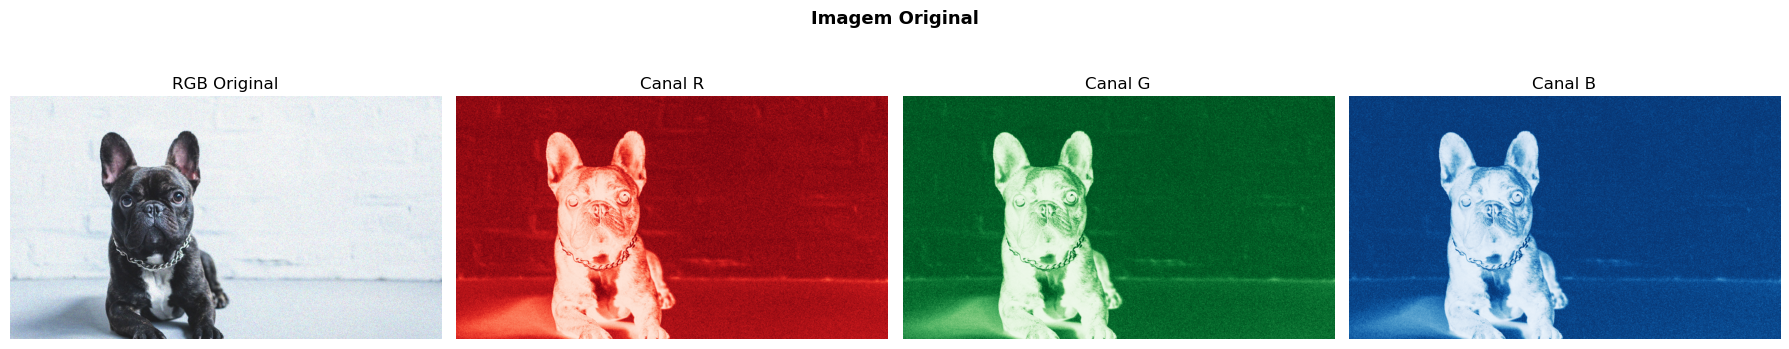

  [salvo] results/imagem_original.png


In [375]:
# Visualização da imagem original e seus canais RGB
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Imagem Original', fontsize=13, fontweight='bold')
axes[0].imshow(img);                        axes[0].set_title('RGB Original');  axes[0].axis('off')
axes[1].imshow(img[:,:,0], cmap='Reds');    axes[1].set_title('Canal R');       axes[1].axis('off')
axes[2].imshow(img[:,:,1], cmap='Greens');  axes[2].set_title('Canal G');       axes[2].axis('off')
axes[3].imshow(img[:,:,2], cmap='Blues');   axes[3].set_title('Canal B');       axes[3].axis('off')
plt.tight_layout()
save_result('imagem_original.png')

# Escala de cinza

Nesta etapa, foi implementada a conversão manual da imagem RGB para escala de cinza. O processo utiliza a fórmula de luminância ponderada, que atribui diferentes pesos aos canais vermelho, verde e azul de acordo com a percepção visual humana.

A conversão para grayscale reduz a complexidade da imagem, transformando-a em uma matriz bidimensional de intensidades, o que facilita as próximas etapas de processamento e detecção de bordas.

In [376]:
# Aplica a fórmula da luminância para converter a imagem para escala de cinza
def to_grayscale(img: np.ndarray) -> np.ndarray:
    R = img[:, :, 0].astype(np.float64)
    G = img[:, :, 1].astype(np.float64)
    B = img[:, :, 2].astype(np.float64)
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    return np.clip(np.round(gray), 0, 255).astype(np.uint8)

gray = to_grayscale(img)

Nesta etapa, a imagem é convertida para escala de cinza utilizando a função implementada anteriormente. Em seguida, são exibidas informações como dimensões da matriz, tipo de dado e estatísticas básicas de intensidade dos pixels.

Essas verificações auxiliam na validação do processamento realizado e garantem que a imagem esteja adequada para as próximas etapas do pipeline.

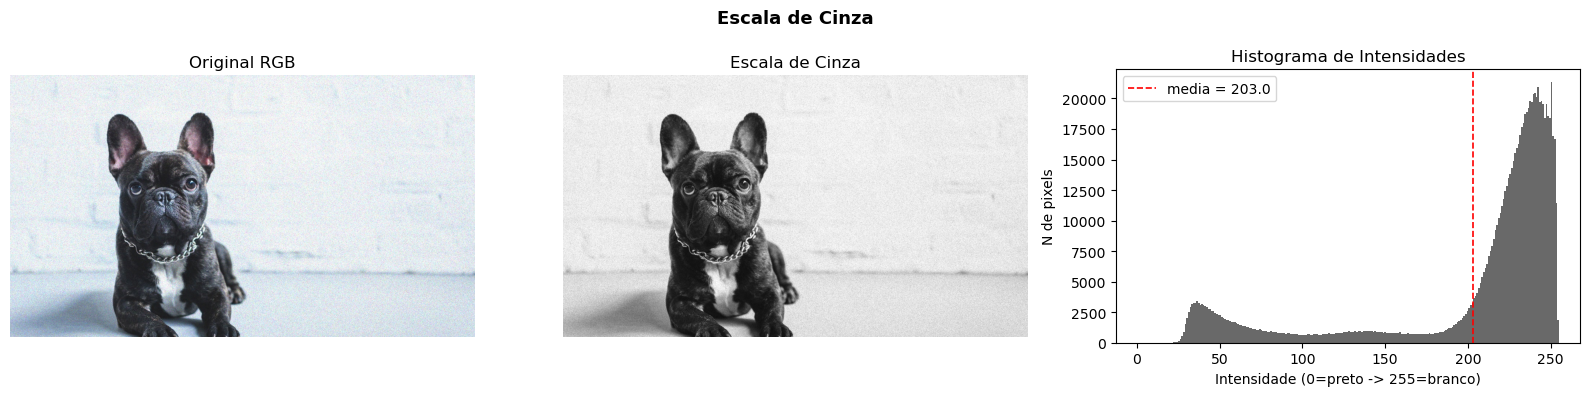

  [salvo] results/escala_de_cinza.png


In [377]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Escala de Cinza', fontsize=13, fontweight='bold')

axes[0].imshow(img);                 axes[0].set_title('Original RGB'); axes[0].axis('off')
axes[1].imshow(gray, cmap='gray');   axes[1].set_title('Escala de Cinza'); axes[1].axis('off')

axes[2].hist(gray.ravel(), bins=256, range=(0,255), color='dimgray', edgecolor='none')
axes[2].set_title('Histograma de Intensidades')
axes[2].set_xlabel('Intensidade (0=preto -> 255=branco)')
axes[2].set_ylabel('N de pixels')
axes[2].axvline(gray.mean(), color='red', linestyle='--', linewidth=1.2, label=f'media = {gray.mean():.1f}')
axes[2].legend()
plt.tight_layout()
save_result('escala_de_cinza.png')

# Filtro Gaussiano

Nesta etapa, foi implementado manualmente o processo de suavização da imagem utilizando o filtro gaussiano. A função `make_gaussian_kernel()` gera um kernel normalizado, garantindo que a intensidade m?dia da imagem seja preservada após a convolução.

A escolha de `size=5` e `sigma=1.0` foi feita para equilibrar dois objetivos: reduzir ruído local que atrapalha a detecãoo de bordas e, ao mesmo tempo, preservar estruturas importantes do contorno do cachorro. Kernels maiores ou sigma mais alto aumentam a suavização, mas tendem a apagar detalhes finos (como focinho e olhos).

Essa suavização antes do Sobel é importante porque o operador de gradiente é sensível a variações bruscas de intensidade, incluindo ruído. Portanto, aplicar o gaussiano antes reduz falsas bordas e melhora a estabilidade do mapa de gradientes.


In [378]:
# Cria a matriz do kernel gaussiano
def make_gaussian_kernel(size: int = 5, sigma: float = 1.0) -> np.ndarray:
    half = size // 2
    coords = np.arange(-half, half + 1, dtype=np.float64)
    x, y = np.meshgrid(coords, coords)
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

# Convolução manual utilizando o kernel
def convolve2d(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    H, W = img.shape
    kH, kW = kernel.shape
    pad_h, pad_w = kH // 2, kW // 2
    img_padded = np.zeros((H + 2*pad_h, W + 2*pad_w), dtype=np.float64)
    img_padded[pad_h:pad_h+H, pad_w:pad_w+W] = img
    output = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            output[i, j] = np.sum(img_padded[i:i+kH, j:j+kW] * kernel)
    return output

# Aplica o filtro gaussiano à imagem em escala de cinza
def gaussian_blur(gray: np.ndarray, size: int = 5, sigma: float = 1.0) -> np.ndarray:
    kernel = make_gaussian_kernel(size, sigma)
    blurred = convolve2d(gray.astype(np.float64), kernel)
    return np.clip(np.round(blurred), 0, 255).astype(np.uint8)

Nesta etapa, a imagem em escala de cinza é reduzida por amostragem com salto (`scale=4`) para criar uma vers?o de baixa resolução usada apenas para inspeção visual rápida e testes exploratórios de par?metros.

A motivação é acelerar iterações de análise sem alterar a lógica principal da pipeline. Como o downsampling reduz detalhe espacial e pode deslocar bordas finas, ele não é adotado como base da saída final de contornos exportada para o turtlesim.


In [379]:
scale = 4
small = gray[::scale, ::scale]
blurred = gaussian_blur(small, size=5, sigma=1.0)

Nesta visualização, o objetivo é comparar o efeito do filtro gaussiano na versão reduzida da imagem para observar rapidamente o comportamento de suavização antes da etapa de gradiente.

Essa comparação ajuda a validar o trade-off ruído vs. preservação de forma: menos ruído facilita o Sobel, mas excesso de suavização reduz detalhes. A configuração escolhida foi mantida por apresentar bom equilíbrio na forma geral do cachorro.


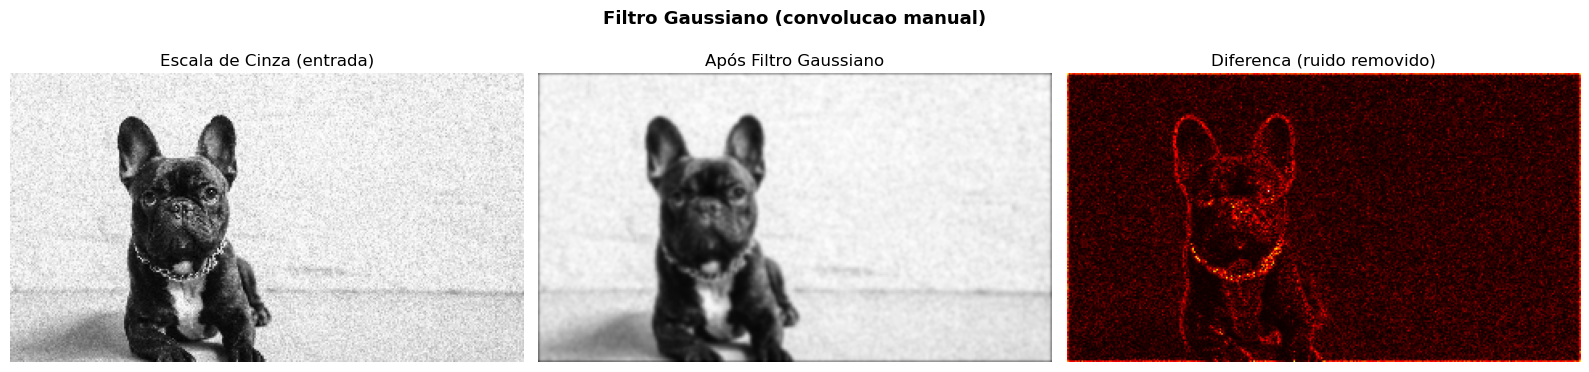

  [salvo] results/gaussian_blur.png


In [380]:
# Visualização do resultado do filtro gaussiano
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Filtro Gaussiano (convolucao manual)', fontsize=13, fontweight='bold')
axes[0].imshow(small,    cmap='gray'); axes[0].set_title('Escala de Cinza (entrada)'); axes[0].axis('off')
axes[1].imshow(blurred,  cmap='gray'); axes[1].set_title('Após Filtro Gaussiano'); axes[1].axis('off')
diff = np.abs(small.astype(np.int16) - blurred.astype(np.int16)).astype(np.uint8)
axes[2].imshow(diff, cmap='hot');      axes[2].set_title('Diferenca (ruido removido)'); axes[2].axis('off')
plt.tight_layout()
save_result('gaussian_blur.png')

# Detecção de bordas

Nesta etapa, foi implementado manualmente o detector de bordas de Sobel. O método foi escolhido por ser simples, interpretável e adequado para extrair mudanças locais de intensidade sem uso de fun??es prontas de vis?o computacional.

Os kernels `Gx` e `Gy` estimam o gradiente horizontal e vertical. Em seguida, a magnitude `sqrt(Gx^2 + Gy^2)` combina as duas direções e fornece uma medida única de força de borda por pixel.

Após normalização da magnitude, é aplicado um limiar binário para separar bordas relevantes de variações fracas. Esse passo é necessário para transformar o mapa de gradientes em uma máscara de bordas utilizável nas etapas de conectividade e rastreamento.


In [381]:
# Aplica o operador Sobel para detectar bordas
def sobel_edges(blurred: np.ndarray, threshold: int = 30) -> tuple:
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    kernel_y = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=np.float64)

    img_f = blurred.astype(np.float64)
    Gx = convolve2d(img_f, kernel_x)
    Gy = convolve2d(img_f, kernel_y)

    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude_norm = magnitude / magnitude.max() * 255
    edges = (magnitude_norm > threshold).astype(np.uint8) * 255
    return edges, magnitude_norm

edges, magnitude = sobel_edges(blurred, threshold=39)

# Remove bordas artificiais da imagem
edges[:5, :] = 0
edges[-5:, :] = 0
edges[:, :5] = 0
edges[:, -5:] = 0

n_bordas = (edges == 255).sum()

Nesta etapa, são apresentados os resultados da detecção de bordas com Sobel. A análise visual desses resultados foi usada para calibrar o limiar da binarização.

No pipeline final, foi adotado `threshold = 39` por ajuste empírico: limiares mais baixos preservavam mais detalhe, mas introduziam ruído e fragmentação; limiares mais altos limpavam o mapa, porém removiam partes importantes do contorno (especialmente detalhes internos).

Esse valor intermediário manteve a silhueta principal com boa continuidade e ainda preservou detalhes úteis para as etapas seguintes de contorno.


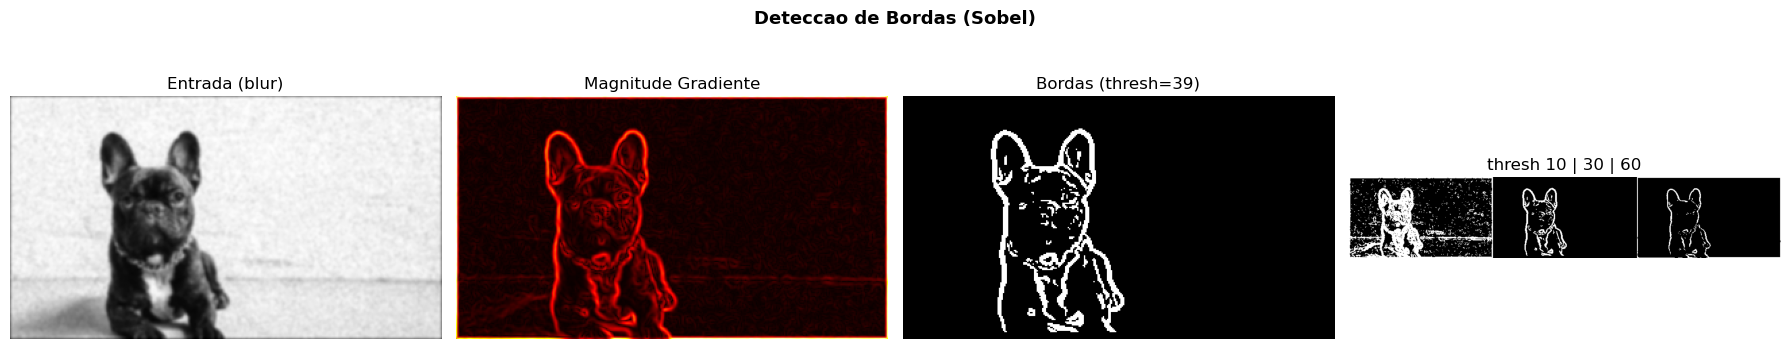

  [salvo] results/sobel_edges.png


In [382]:
# Visualização do resultado da detecção de bordas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Deteccao de Bordas (Sobel)', fontsize=13, fontweight='bold')
axes[0].imshow(blurred,   cmap='gray'); axes[0].set_title('Entrada (blur)');      axes[0].axis('off')
axes[1].imshow(magnitude, cmap='hot');  axes[1].set_title('Magnitude Gradiente'); axes[1].axis('off')
axes[2].imshow(edges,     cmap='gray'); axes[2].set_title('Bordas (thresh=39)');  axes[2].axis('off')
e10, _ = sobel_edges(blurred, 10)
e60, _ = sobel_edges(blurred, 60)
axes[3].imshow(np.hstack([e10, edges, e60]), cmap='gray')
axes[3].set_title('thresh 10 | 30 | 60'); axes[3].axis('off')
plt.tight_layout()
save_result('sobel_edges.png')

# Extração de contorno

Nesta etapa, foi implementado um algoritmo de identificação de componentes conectados utilizando busca em largura (BFS). O objetivo é separar grupos independentes de pixels de borda presentes na imagem, permitindo tratar individualmente diferentes regiões do contorno detectado.

O algoritmo percorre toda a imagem binária e, ao encontrar um pixel branco ainda não visitado, inicia uma BFS considerando conectividade em 8 direções. Todos os pixels conectados pertencentes à mesma região são agrupados em um único componente.

Essa abordagem permite isolar diferentes partes relevantes da imagem, como contornos externos e detalhes internos, preparando os dados para as próximas etapas de rastreamento de trajetória contínua.

In [383]:
# Extrai trajetorias continuas com alta fidelidade ao edges (thresh=39)
def connected_components(edges: np.ndarray) -> list:
    H, W = edges.shape
    visited = np.zeros((H, W), dtype=bool)
    neighbors8 = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    comps = []

    for r in range(H):
        for c in range(W):
            if edges[r, c] != 255 or visited[r, c]:
                continue

            q = deque([(r, c)])
            visited[r, c] = True
            comp = []

            while q:
                cr, cc = q.popleft()
                comp.append((cr, cc))
                for dr, dc in neighbors8:
                    nr, nc = cr + dr, cc + dc
                    if 0 <= nr < H and 0 <= nc < W and not visited[nr, nc] and edges[nr, nc] == 255:
                        visited[nr, nc] = True
                        q.append((nr, nc))

            comps.append(comp)

    return comps

Nesta etapa, foi implementado um fechamento leve de lacunas nas bordas detectadas. A função `bridge_small_gaps()` conecta apenas descontinuidades locais pequenas (principalmente de 1 pixel), sem aplicar operações morfológicas prontas.

A escolha de `iters=1` no fluxo final foi intencional: é o mínimo necessário para recuperar continuidade em trechos quebrados, evitando deformar o formato original ou criar conexões artificiais entre regiões distintas.


In [384]:
def bridge_small_gaps(binary_edges: np.ndarray, iters: int = 1) -> np.ndarray:
    # Fecha apenas lacunas locais de 1 pixel para manter fidelidade ao Sobel
    m = (binary_edges == 255).astype(np.uint8)
    H, W = m.shape

    for _ in range(iters):
        out = m.copy()
        for r in range(1, H - 1):
            for c in range(1, W - 1):
                if m[r, c] == 1:
                    continue

                n = m[r-1:r+2, c-1:c+2]

                # Conecta segmentos opostos separados por 1 pixel
                if (n[1, 0] and n[1, 2]) or (n[0, 1] and n[2, 1]):
                    out[r, c] = 1
                    continue
                if (n[0, 0] and n[2, 2]) or (n[0, 2] and n[2, 0]):
                    out[r, c] = 1
                    continue

                # Se ha muitos vizinhos de borda, completa o ponto central
                if n.sum() >= 5:
                    out[r, c] = 1

        m = out

    return (m * 255).astype(np.uint8)



Nesta etapa, foi implementado o rastreamento contínuo dos contornos utilizando o algoritmo de Moore Neighbor Tracing. Inicialmente, cada componente conectado é convertido em uma máscara binária individual, permitindo o processamento isolado de cada região detectada.

Em seguida, o algoritmo identifica os pixels pertencentes à borda externa do componente e inicia o rastreamento a partir de um ponto inicial. A trajetória é construída percorrendo iterativamente os vizinhos em 8 direções, seguindo a continuidade geométrica do contorno.

In [385]:
def component_to_mask(shape: tuple, comp: list) -> np.ndarray:
    m = np.zeros(shape, dtype=np.uint8)
    for r, c in comp:
        m[r, c] = 255
    return m


def border_pixels(component_mask: np.ndarray) -> list:
    H, W = component_mask.shape
    pts = []

    for r in range(1, H - 1):
        for c in range(1, W - 1):
            if component_mask[r, c] != 255:
                continue
            if np.any(component_mask[r-1:r+2, c-1:c+2] == 0):
                pts.append((r, c))

    return pts


def trace_component_external_contour(component_mask: np.ndarray,
                                     min_points: int = 20,
                                     max_points: int = 12000) -> np.ndarray:
    # Extrai contorno externo via Moore Neighbor Tracing
    border = border_pixels(component_mask)
    if not border:
        return np.empty((0, 2), dtype=np.int32)

    start = min(border)  # ponto mais ao topo/esquerda tende a cair no contorno externo
    border_set = set(border)

    dirs = [(-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)]
    dir_to_idx = {d: i for i, d in enumerate(dirs)}

    contour = [start]
    current = start
    previous = (start[0], start[1] - 1)

    for _ in range(max_points - 1):
        in_dir = (previous[0] - current[0], previous[1] - current[1])
        start_idx = dir_to_idx.get(in_dir, 6)

        found = None
        for k in range(8):
            idx = (start_idx + 1 + k) % 8
            dr, dc = dirs[idx]
            nxt = (current[0] + dr, current[1] + dc)
            if nxt in border_set:
                found = (nxt, idx)
                break

        if found is None:
            break

        nxt, idx = found
        contour.append(nxt)

        back_idx = (idx + 4) % 8
        br, bc = dirs[back_idx]
        previous = (nxt[0] + br, nxt[1] + bc)
        current = nxt

        if current == start and len(contour) > 10:
            break

    contour = np.array(contour, dtype=np.int32)
    if len(contour) < min_points:
        return np.empty((0, 2), dtype=np.int32)

    return contour



Nesta etapa, o pipeline final de extração de contorno é executado sobre o mapa de bordas refinado. Primeiro, pequenos gaps são fechados; depois, componentes conectados são extraídos; por fim, cada componente é rastreado com Moore Neighbor Tracing para produzir trajetórias contínuas.

Foi mantido `min_component_size = 8` para preservar também estruturas menores que contribuem para fidelidade visual (como traços internos), evitando descartar tudo que não pertence à silhueta grossa principal.

Posteriormente, no pipeline do turtlesim, é possível optar por usar apenas o contorno principal para priorizar estabilidade de desenho e reduzir ambiguidade de trajetória do robô.


In [386]:
# 1) Mantem o Sobel original e aplica apenas um fechamento leve de lacunas
edges_refined = bridge_small_gaps(edges, iters=1)

# 2) Seleciona componentes menores tambem (olhos/focinho)
all_components = connected_components(edges_refined)
min_component_size = 8
selected_components = [c for c in all_components if len(c) >= min_component_size]
selected_components.sort(key=len, reverse=True)

# 3) Mascara final dos componentes escolhidos
component = np.zeros_like(edges, dtype=np.uint8)
for comp in selected_components:
    for r, c in comp:
        component[r, c] = 255

# 4) Para cada componente, pega somente o contorno externo
contours = []
for comp in selected_components:
    cmask = component_to_mask(edges.shape, comp)
    ct = trace_component_external_contour(cmask, min_points=20)
    if len(ct) > 0:
        contours.append(ct)

if contours:
    contour = np.vstack([
        np.vstack([ct, np.array([[-1, -1]], dtype=np.int32)])
        for ct in contours
    ])
else:
    contour = np.empty((0, 2), dtype=np.int32)



Nesta etapa, são apresentados os resultados finais do processo de refinamento e rastreamento dos contornos. A primeira visualização mostra as bordas originais obtidas pelo operador de Sobel com threshold = 39, enquanto a segunda apresenta o resultado após o fechamento de pequenas lacunas locais.

Na terceira imagem, são exibidos os componentes conectados rastreados individualmente pelo algoritmo de Moore Neighbor Tracing. Cada trajetória é desenhada separadamente, preservando a continuidade geométrica dos contornos e evitando conexões artificiais entre regiões independentes da imagem.

O resultado final corresponde a um conjunto de trajetórias contínuas e organizadas, adequadas para posterior conversão em movimentos no ambiente turtlesim.

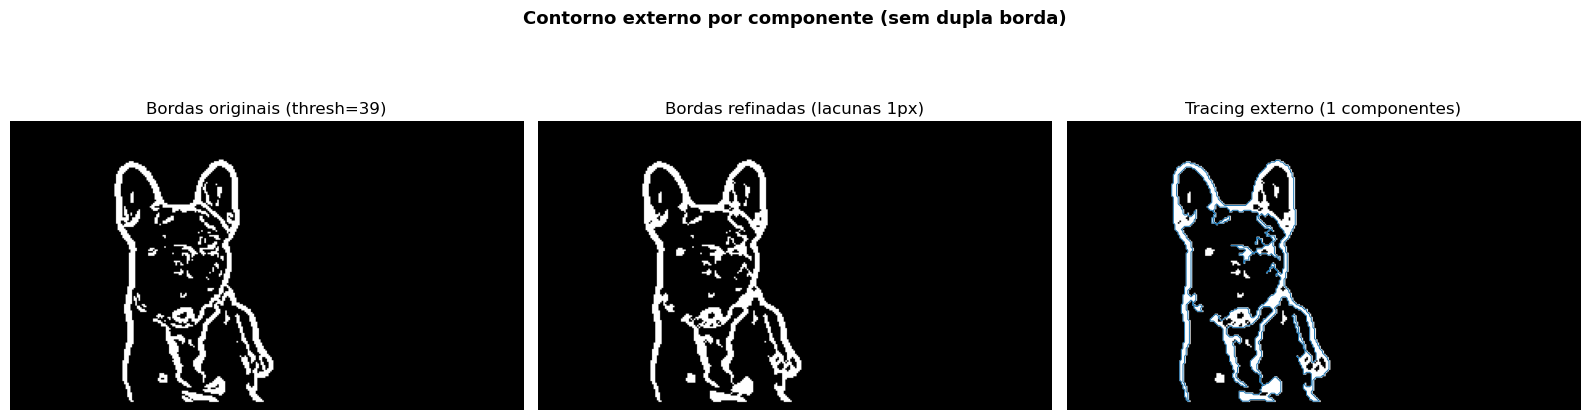

  [salvo] results/contorno_bfs.png


In [387]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Contorno externo por componente (sem dupla borda)', fontsize=13, fontweight='bold')

axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Bordas originais (thresh=39)')
axes[0].axis('off')

axes[1].imshow(edges_refined, cmap='gray')
axes[1].set_title('Bordas refinadas (lacunas 1px)')
axes[1].axis('off')

axes[2].imshow(component, cmap='gray')
for ct in contours:
    axes[2].plot(ct[:,1], ct[:,0], linewidth=0.7)
axes[2].set_title(f'Tracing externo ({len(contours)} componentes)')
axes[2].axis('off')

plt.tight_layout()
save_result('contorno_bfs.png')



Nesta etapa final, os principais artefatos gerados ao longo do pipeline de visão são exportados para arquivos em disco, permitindo a integração direta com o notebook de mapeamento e controle no turtlesim. São salvas a matriz de bordas original (threshold 39), a versão refinada das bordas, a máscara final de componentes selecionados e os contornos contínuos rastreados. Com isso, o próximo estágio do projeto pode reutilizar exatamente os dados processados, garantindo consist?ncia entre a extração visual e a execução do desenho no ROS 2.


In [388]:
# Exporta artefatos finais para o pipeline_turtlesim.ipynb
VISAO_EDGES_NPY = os.path.join(RESULTS_DIR, 'visao_edges_thresh39.npy')
VISAO_EDGES_REFINED_NPY = os.path.join(RESULTS_DIR, 'visao_edges_refined.npy')
VISAO_COMPONENT_NPY = os.path.join(RESULTS_DIR, 'visao_component_mask.npy')
VISAO_CONTOURS_NPZ = os.path.join(RESULTS_DIR, 'visao_contours_tracing.npz')

np.save(VISAO_EDGES_NPY, edges.astype(np.uint8))
np.save(VISAO_EDGES_REFINED_NPY, edges_refined.astype(np.uint8))
np.save(VISAO_COMPONENT_NPY, component.astype(np.uint8))
np.savez(
    VISAO_CONTOURS_NPZ,
    contours=np.array(contours, dtype=object),
    image_shape=np.array(edges.shape, dtype=np.int32),
)

print('Artefatos exportados para o pipeline turtlesim:')
print(' -', VISAO_EDGES_NPY)
print(' -', VISAO_EDGES_REFINED_NPY)
print(' -', VISAO_COMPONENT_NPY)
print(' -', VISAO_CONTOURS_NPZ)



Artefatos exportados para o pipeline turtlesim:
 - results\visao_edges_thresh39.npy
 - results\visao_edges_refined.npy
 - results\visao_component_mask.npy
 - results\visao_contours_tracing.npz
